In [1]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.linalg import expm
from scipy.interpolate import interp1d
from IPython.display import display

warnings.filterwarnings('ignore')

# Quantum chemistry
from pyscf import gto, scf, ao2mo
from openfermion import (FermionOperator, normal_ordered, jordan_wigner,
                         get_sparse_operator, count_qubits)

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


In [2]:
ORCA_OUTPUT_DIR  = './input_2'            # 📂 Folder berisi file .out ORCA
BOND_LENGTHS_VQE = np.arange(0.30, 2.55, 0.10)  # Grid VQE (Å)

METHOD_VQE   = 'COBYLA'  # Optimizer: 'COBYLA', 'BFGS', 'L-BFGS-B'
N_RESTARTS   = 5
SEED         = 42
N_ELECTRONS  = 2
N_QUBITS     = 4

print(f'📌 Konfigurasi:')
print(f'   ORCA folder  : {ORCA_OUTPUT_DIR}')
print(f'   Bond lengths : {BOND_LENGTHS_VQE[0]:.2f} – {BOND_LENGTHS_VQE[-1]:.2f} Å  ({len(BOND_LENGTHS_VQE)} titik)')
print(f'   Optimizer    : {METHOD_VQE}  |  Restarts: {N_RESTARTS}  |  Seed: {SEED}')
print(f'   Qubits       : {N_QUBITS}  |  Elektron: {N_ELECTRONS}')

📌 Konfigurasi:
   ORCA folder  : ./input_2
   Bond lengths : 0.30 – 2.50 Å  (23 titik)
   Optimizer    : COBYLA  |  Restarts: 5  |  Seed: 42
   Qubits       : 4  |  Elektron: 2


In [3]:
import os, glob, re
import pandas as pd
from IPython.display import display

# ── Path yang benar (handle nama folder dengan spasi) ─────────────────
BASE_DIR = os.path.join(os.path.expanduser('~'), 'Benchmarking VQE dan ORCA')
ORCA_OUTPUT_DIR = os.path.join(BASE_DIR, 'inputs_casscf')

# ── Diagnosis path ────────────────────────────────────────────────────
cwd = os.getcwd()
print('=== DIAGNOSIS PATH ===')
print('Working directory :', cwd)
print('ORCA_OUTPUT_DIR   :', ORCA_OUTPUT_DIR)
print('Absolute path     :', os.path.abspath(ORCA_OUTPUT_DIR))
print('Folder exists?    :', os.path.isdir(os.path.abspath(ORCA_OUTPUT_DIR)))

# Kandidat folder — prioritaskan path yang benar dulu
CANDIDATE_DIRS = [
    ORCA_OUTPUT_DIR,                                        # ~/h2 untuk banyak energy/inputs
    BASE_DIR,                                               # ~/h2 untuk banyak energy/
    os.path.join(cwd, 'Benchmarking VQE dan ORCA', 'inputs_casscf'), # fallback relatif
    os.path.join(cwd, 'Benchmarking VQE dan ORCA'),
    os.path.join(cwd, 'inputs'),
    '.',
]

# ── Fungsi deteksi & parser ───────────────────────────────────────────
def is_orca_out(filepath):
    """Cek apakah file .out adalah output ORCA, bukan SLURM/log biasa."""
    try:
        with open(filepath, 'r', errors='replace') as f:
            for i, line in enumerate(f):
                if 'O   R   C   A' in line or 'FINAL SINGLE POINT ENERGY' in line:
                    return True
                if i > 60:
                    break
    except Exception:
        pass
    return False


def find_orca_files(candidates):
    """Cari semua file .out ORCA dari daftar kandidat folder."""
    all_orca = []
    seen_dirs = set()
    for d in candidates:
        d = os.path.abspath(d)
        if d in seen_dirs or not os.path.isdir(d):
            continue
        seen_dirs.add(d)
        found = sorted(glob.glob(os.path.join(d, '*.out')))
        orca = [f for f in found if is_orca_out(f)]
        if orca:
            print(f'  ✓ Ditemukan di: {d}  →  {len(orca)} file')
            all_orca.extend(orca)
        else:
            print(f'  ✗ Kosong      : {d}')
    return all_orca


def parse_bond_length_from_filename(filename):
    """
    Ekstrak panjang ikatan dari nama file.
    Contoh: h2_0.75.out -> 0.75, h2_2.35.out -> 2.35
    """
    base = os.path.basename(filename)
    for m in re.findall(r'(\d+\.\d+)', base):
        val = float(m)
        if 0.10 <= val <= 9.99:
            return round(val, 4)
    for m in re.findall(r'[_\-](\d{2,4})(?=[^\d]|$)', base):
        val = float(m)
        while val >= 10:
            val /= 100
        if 0.10 <= val <= 9.99:
            return round(val, 4)
    return None


def parse_orca_energy(filepath):
    """Baca FINAL SINGLE POINT ENERGY terakhir dari file .out ORCA."""
    energy = None
    pattern = re.compile(r'FINAL SINGLE POINT ENERGY\s+([\-\d.]+)')
    try:
        with open(filepath, 'r', errors='replace') as f:
            for line in f:
                m = pattern.search(line)
                if m:
                    energy = float(m.group(1))  # ambil nilai terakhir
    except Exception as e:
        print(f'  Gagal baca {os.path.basename(filepath)}: {e}')
    return energy


def load_orca_data(file_list):
    """
    Baca energi dari semua file ORCA .out.
    Return dict terurut: {bond_length: energy_Ha}
    """
    if not file_list:
        print('⚠ Tidak ada file ORCA .out untuk dibaca.')
        return {}

    data = {}
    rows = []
    for fp in sorted(file_list):
        fname = os.path.basename(fp)
        if fname.startswith('slurm') or fname.startswith('error'):
            continue
        R = parse_bond_length_from_filename(fp)
        E = parse_orca_energy(fp)
        if R is None:
            status = 'SKIP – R tidak terbaca'
        elif E is None:
            status = 'SKIP – energi tidak ada'
        else:
            status = 'OK'
            data[R] = E
        rows.append({'File': fname, 'R (Å)': R, 'E_ORCA (Ha)': E, 'Status': status})

    if rows:
        display(pd.DataFrame(rows))
    return dict(sorted(data.items()))


# ── Jalankan ──────────────────────────────────────────────────────────
print('\nMencari file ORCA .out ...')
detected_files = find_orca_files(CANDIDATE_DIRS)

if not detected_files:
    print('\n⚠ Tidak ditemukan. Isi direktori yang relevan:')
    for d in [BASE_DIR, ORCA_OUTPUT_DIR, cwd]:
        if os.path.isdir(d):
            files = sorted(os.listdir(d))[:20]
            print(f'\n  [{d}]')
            for f in files:
                print(f'    {f}')
print('=====================')

orca_data = load_orca_data(detected_files)
print(f'\nTotal data ORCA terbaca: {len(orca_data)} titik')
if orca_data:
    print('Bond lengths (Å):', sorted(orca_data.keys()))

=== DIAGNOSIS PATH ===
Working directory : /mgpfs/home/mkhairiansyah
ORCA_OUTPUT_DIR   : /mgpfs/home/mkhairiansyah/Benchmarking VQE dan ORCA/inputs_casscf
Absolute path     : /mgpfs/home/mkhairiansyah/Benchmarking VQE dan ORCA/inputs_casscf
Folder exists?    : True

Mencari file ORCA .out ...


  ✓ Ditemukan di: /mgpfs/home/mkhairiansyah/Benchmarking VQE dan ORCA/inputs_casscf  →  45 file
  ✗ Kosong      : /mgpfs/home/mkhairiansyah/Benchmarking VQE dan ORCA
  ✓ Ditemukan di: /mgpfs/home/mkhairiansyah  →  1 file


,File,R (Å),E_ORCA (Ha),Status
0,h2_0.30.out,0.30,-0.601804,OK
1,h2_0.35.out,0.35,-0.789269,OK
2,h2_0.40.out,0.40,-0.914150,OK
3,h2_0.45.out,0.45,-0.998416,OK
4,h2_0.50.out,0.50,-1.055160,OK
5,h2_0.55.out,0.55,-1.092630,OK
6,h2_0.60.out,0.60,-1.116286,OK
7,h2_0.65.out,0.65,-1.129905,OK
8,h2_0.70.out,0.70,-1.136189,OK
9,h2_0.75.out,0.75,-1.137117,OK



Total data ORCA terbaca: 45 titik
Bond lengths (Å): [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5]


In [4]:
def build_one_electron(integral, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            if abs(integral[p, q]) < 1e-12:
                continue
            for sigma in range(2):
                i = 2 * p + sigma
                j = 2 * q + sigma
                H += FermionOperator(((i, 1), (j, 0)), integral[p, q])
    return H


def build_two_electron(eri_mo, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            for r in range(n_orb):
                for s in range(n_orb):
                    g = eri_mo[p, q, r, s]
                    if abs(g) < 1e-12:
                        continue
                    for sigma in range(2):
                        for tau in range(2):
                            i = 2 * p + sigma
                            j = 2 * r + tau
                            k = 2 * s + tau
                            l = 2 * q + sigma
                            H += FermionOperator(
                                ((i, 1), (j, 1), (k, 0), (l, 0)), 0.5 * g)
    return H


def build_hamiltonian(bond_length):
    mol = gto.Mole()
    mol.atom = f'H 0 0 0; H 0 0 {bond_length}'
    mol.basis = 'sto-3g'
    mol.verbose = 0
    mol.build()

    mf = scf.RHF(mol)
    mf.run()
    C = mf.mo_coeff
    n_orb = C.shape[1]
    E_nuc = mol.energy_nuc()

    T_ao = mol.intor('int1e_kin')
    V_ao = mol.intor('int1e_nuc')
    T_mo = C.T @ T_ao @ C
    V_mo = C.T @ V_ao @ C
    eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(
        n_orb, n_orb, n_orb, n_orb)

    H_Kin = normal_ordered(build_one_electron(T_mo, n_orb))
    H_VeN = normal_ordered(build_one_electron(V_mo, n_orb))
    H_Vee = normal_ordered(build_two_electron(eri_mo, n_orb))

    T_q = jordan_wigner(H_Kin)
    VeN_q = jordan_wigner(H_VeN)
    Vee_q = jordan_wigner(H_Vee)
    V_q = VeN_q + Vee_q
    n_q = count_qubits(T_q + V_q)

    T_mat = get_sparse_operator(T_q, n_qubits=n_q).toarray()
    V_mat = get_sparse_operator(V_q, n_qubits=n_q).toarray()
    H_mat = T_mat + V_mat

    return H_mat, E_nuc, n_q


# ── Uji cepat R = 0.74 Å ─────────────────────────────────────────────
print('🔧 Uji Hamiltonian pada R = 0.74 Å ...')
H_test, E_nuc_test, n_q_test = build_hamiltonian(0.74)
evals_test, _ = np.linalg.eigh(H_test)
E_fci_test = evals_test[0] + E_nuc_test
print(f'   n_qubits   = {n_q_test}')
print(f'   dim Hilbert = {2**n_q_test} × {2**n_q_test}')
print(f'   E_nuc       = {E_nuc_test:.6f} Ha')
print(f'   E_FCI       = {E_fci_test:.8f} Ha')
print('✅ Hamiltonian OK')

🔧 Uji Hamiltonian pada R = 0.74 Å ...
   n_qubits   = 4
   dim Hilbert = 16 × 16
   E_nuc       = 0.715104 Ha
   E_FCI       = -1.13728383 Ha
✅ Hamiltonian OK


In [5]:
# ── HF State ─────────────────────────────────────────────────────────
def prepare_hf_state(n_qubits, n_electrons):
    psi = np.zeros(2 ** n_qubits, dtype=complex)
    hf_idx = sum(1 << (n_qubits - 1 - i) for i in range(n_electrons))
    psi[hf_idx] = 1.0
    return psi


# ── Generator Eksitasi UCCSD ──────────────────────────────────────────
def build_single_excitation_generator(i, a, n_qubits):
    op = (FermionOperator(((a, 1), (i, 0))) -
          FermionOperator(((i, 1), (a, 0))))
    return get_sparse_operator(jordan_wigner(op), n_qubits=n_qubits).toarray()


def build_double_excitation_generator(i, j, a, b, n_qubits):
    op = (FermionOperator(((a, 1), (b, 1), (j, 0), (i, 0))) -
          FermionOperator(((i, 1), (j, 1), (b, 0), (a, 0))))
    return get_sparse_operator(jordan_wigner(op), n_qubits=n_qubits).toarray()


def get_uccsd_excitations(n_electrons, n_qubits):
    n_occ = n_electrons
    singles = [(i, a) for i in range(n_occ) for a in range(n_occ, n_qubits)]
    doubles = [(i, j, a, b)
               for i in range(n_occ) for j in range(i + 1, n_occ)
               for a in range(n_occ, n_qubits) for b in range(a + 1, n_qubits)]
    return singles, doubles


def count_uccsd_params(n_electrons, n_qubits):
    s, d = get_uccsd_excitations(n_electrons, n_qubits)
    return len(s) + len(d)


# ── Ansatz: |ψ(θ)⟩ = ∏_k exp(θ_k G_k) |HF⟩ ──────────────────────────
def prepare_ansatz(params, n_qubits, n_electrons):
    psi = prepare_hf_state(n_qubits, n_electrons)
    singles, doubles = get_uccsd_excitations(n_electrons, n_qubits)
    idx = 0
    for (i, a) in singles:
        G = build_single_excitation_generator(i, a, n_qubits)
        psi = expm(params[idx] * G) @ psi
        idx += 1
    for (i, j, a, b) in doubles:
        G = build_double_excitation_generator(i, j, a, b, n_qubits)
        psi = expm(params[idx] * G) @ psi
        idx += 1
    return psi


# ── Nilai Ekspektasi ──────────────────────────────────────────────────
def expect_value(psi, H_mat):
    return float(np.real(psi.conj() @ H_mat @ psi))


# ── Runner VQE ────────────────────────────────────────────────────────
def run_vqe(H_mat, n_qubits, n_electrons,
            method='COBYLA', n_restarts=5, seed=42):
    rng = np.random.RandomState(seed)
    n_params = count_uccsd_params(n_electrons, n_qubits)
    best = {'E_vqe': np.inf, 'n_iters': 0}

    opts_map = {
        'COBYLA':   {'maxiter': 3000, 'rhobeg': 0.5},
        'BFGS':     {'maxiter': 1000, 'gtol': 1e-8},
        'L-BFGS-B': {'maxiter': 1000, 'ftol': 1e-12},
    }
    opts = opts_map.get(method, {'maxiter': 2000})

    for trial in range(n_restarts):
        history = []

        def cost(p):
            psi = prepare_ansatz(p, n_qubits, n_electrons)
            E = expect_value(psi, H_mat)
            history.append(E)
            return E

        theta0 = (rng.uniform(-0.3, 0.3, n_params)
                  if trial < n_restarts // 2
                  else rng.uniform(-np.pi, np.pi, n_params))

        res = minimize(cost, theta0, method=method, options=opts)

        if res.fun < best['E_vqe']:
            best = {'E_vqe': res.fun,
                    'optimal_params': res.x.copy(),
                    'n_iters': len(history),
                    'trial': trial + 1,
                    'success': res.success}
    return best


# ── Info Konfigurasi UCCSD ────────────────────────────────────────────
n_params = count_uccsd_params(N_ELECTRONS, N_QUBITS)
singles, doubles = get_uccsd_excitations(N_ELECTRONS, N_QUBITS)
print(f'✅ Konfigurasi UCCSD:')
print(f'   Single excitations : {singles}  → {len(singles)} params')
print(f'   Double excitations : {doubles}  → {len(doubles)} params')
print(f'   Total params       : {n_params}')

✅ Konfigurasi UCCSD:
   Single excitations : [(0, 2), (0, 3), (1, 2), (1, 3)]  → 4 params
   Double excitations : [(0, 1, 2, 3)]  → 1 params
   Total params       : 5


In [6]:
results_vqe = []
n_total = len(BOND_LENGTHS_VQE)
SEP = '=' * 65

print(SEP)
print('  Menjalankan VQE UCCSD — ' + str(n_total) + ' titik ikatan')
print('  Optimizer: ' + METHOD_VQE + '  |  Restarts: ' + str(N_RESTARTS) + '  |  Seed: ' + str(SEED))
print(SEP)

for i, R in enumerate(BOND_LENGTHS_VQE):
    print('  [%2d/%d] R = %.2f A ... ' % (i+1, n_total, R), end='', flush=True)
    try:
        H_mat, E_nuc, n_q = build_hamiltonian(R)

        # FCI (eksak dalam basis STO-3G)
        evals, _ = np.linalg.eigh(H_mat)
        E_fci = evals[0] + E_nuc

        # HF
        psi_hf = prepare_hf_state(n_q, N_ELECTRONS)
        E_hf   = expect_value(psi_hf, H_mat) + E_nuc

        # VQE
        vqe   = run_vqe(H_mat, n_q, N_ELECTRONS,
                        method=METHOD_VQE, n_restarts=N_RESTARTS, seed=SEED)
        E_vqe = vqe['E_vqe'] + E_nuc
        dE    = abs(E_vqe - E_fci)
        ca    = 'OK' if dE < 1.6e-3 else 'XX'

        results_vqe.append({
            'R': R, 'E_fci': E_fci, 'E_hf': E_hf,
            'E_vqe': E_vqe, 'dE_vqe': dE,
            'n_iters': vqe['n_iters'],
        })
        n_it = vqe['n_iters']
        print('E_VQE=%+.6f Ha  |dE|=%.2e [%s]  (%d iter)' % (E_vqe, dE, ca, n_it))

    except Exception as e:
        print('GAGAL: ' + str(e))

print('\nSelesai -- %d/%d titik berhasil' % (len(results_vqe), n_total))

  Menjalankan VQE UCCSD — 23 titik ikatan
  Optimizer: COBYLA  |  Restarts: 5  |  Seed: 42
  [ 1/23] R = 0.30 A ... E_VQE=-0.601804 Ha  |dE|=8.83e-09 [OK]  (81 iter)
  [ 2/23] R = 0.40 A ... E_VQE=-0.914150 Ha  |dE|=1.14e-08 [OK]  (75 iter)
  [ 3/23] R = 0.50 A ... E_VQE=-1.055160 Ha  |dE|=7.70e-09 [OK]  (87 iter)
  [ 4/23] R = 0.60 A ... E_VQE=-1.116286 Ha  |dE|=4.20e-09 [OK]  (82 iter)
  [ 5/23] R = 0.70 A ... E_VQE=-1.136189 Ha  |dE|=2.06e-09 [OK]  (83 iter)
  [ 6/23] R = 0.80 A ... E_VQE=-1.134148 Ha  |dE|=3.58e-09 [OK]  (86 iter)
  [ 7/23] R = 0.90 A ... E_VQE=-1.120560 Ha  |dE|=3.71e-09 [OK]  (84 iter)
  [ 8/23] R = 1.00 A ... E_VQE=-1.101150 Ha  |dE|=2.39e-09 [OK]  (87 iter)
  [ 9/23] R = 1.10 A ... E_VQE=-1.079193 Ha  |dE|=2.03e-09 [OK]  (97 iter)
  [10/23] R = 1.20 A ... E_VQE=-1.056741 Ha  |dE|=2.10e-09 [OK]  (84 iter)
  [11/23] R = 1.30 A ... E_VQE=-1.035186 Ha  |dE|=3.98e-09 [OK]  (103 iter)
  [12/23] R = 1.40 A ... E_VQE=-1.015468 Ha  |dE|=4.30e-09 [OK]  (115 iter)
  [13/2

In [7]:
rows = []
for r in results_vqe:
    R     = r['R']
    dE    = r['dE_vqe']
    ca    = '✓' if dE < 1.6e-3 else '✗'

    # Cari energi ORCA terdekat (toleransi ±0.06 Å)
    E_orca_val = None
    for R_o, E_o in orca_data.items():
        if abs(R_o - R) < 0.06:
            E_orca_val = E_o
            break

    # Selisih ORCA vs FCI
    dE_orca = abs(E_orca_val - r['E_fci']) if E_orca_val is not None else None

    rows.append({
        'R (Å)':         round(R, 2),
        'E_FCI (Ha)':    round(r['E_fci'], 8),
        'E_HF (Ha)':     round(r['E_hf'],  8),
        'E_VQE (Ha)':    round(r['E_vqe'], 8),
        '|ΔE_VQE| (Ha)': f'{dE:.3e}',
        'ChAcc':         ca,
        'E_ORCA (Ha)':   round(E_orca_val, 8) if E_orca_val else '—',
        '|ΔE_ORCA| (Ha)':f'{dE_orca:.3e}' if dE_orca is not None else '—',
        'Iter VQE':      r['n_iters'],
    })

df_result = pd.DataFrame(rows)

# Styling
def color_ca(val):
    return 'color: green; font-weight: bold' if val == '✓' else 'color: red'

styled = (df_result.style
    .applymap(color_ca, subset=['ChAcc'])
    .set_caption('📊 Tabel Benchmark: VQE (UCCSD) vs ORCA vs FCI — H₂ STO-3G')
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index'))

display(styled)

# ── Statistik ────────────────────────────────────────────────────────
dE_all = [r['dE_vqe'] for r in results_vqe]
n_ok   = sum(1 for d in dE_all if d < 1.6e-3)
print(f'\n📈 Statistik |ΔE_VQE|:')
print(f'   Rata-rata : {np.mean(dE_all):.3e} Ha')
print(f'   Maksimum  : {np.max(dE_all):.3e} Ha  (R={results_vqe[np.argmax(dE_all)]["R"]:.2f} Å)')
print(f'   Minimum   : {np.min(dE_all):.3e} Ha  (R={results_vqe[np.argmin(dE_all)]["R"]:.2f} Å)')
print(f'   Chemical accuracy: {n_ok}/{len(dE_all)} titik ({100*n_ok/len(dE_all):.0f}%)')

R (Å),E_FCI (Ha),E_HF (Ha),E_VQE (Ha),|ΔE_VQE| (Ha),ChAcc,E_ORCA (Ha),|ΔE_ORCA| (Ha),Iter VQE
0.300000,-0.601804,-0.593828,-0.601804,8.832e-09,✓,-0.601804,6.825e-09,81
0.400000,-0.914150,-0.904361,-0.914150,1.140e-08,✓,-0.789269,1.249e-01,75
0.500000,-1.055160,-1.042996,-1.055160,7.697e-09,✓,-0.998416,5.674e-02,87
0.600000,-1.116286,-1.101128,-1.116286,4.198e-09,✓,-1.092630,2.366e-02,82
0.700000,-1.136189,-1.117349,-1.136189,2.057e-09,✓,-1.129905,6.285e-03,83
0.800000,-1.134148,-1.110850,-1.134148,3.584e-09,✓,-1.137117,2.969e-03,86
0.900000,-1.120560,-1.091914,-1.120560,3.713e-09,✓,-1.128362,7.802e-03,84
1.000000,-1.101150,-1.066109,-1.101150,2.388e-09,✓,-1.111339,1.019e-02,87
1.100000,-1.079193,-1.036539,-1.079193,2.025e-09,✓,-1.090342,1.115e-02,97
1.200000,-1.056741,-1.005107,-1.056741,2.101e-09,✓,-1.067930,1.119e-02,84



📈 Statistik |ΔE_VQE|:
   Rata-rata : 2.614e-08 Ha
   Maksimum  : 2.433e-07 Ha  (R=2.50 Å)
   Minimum   : 2.025e-09 Ha  (R=1.10 Å)
   Chemical accuracy: 23/23 titik (100%)


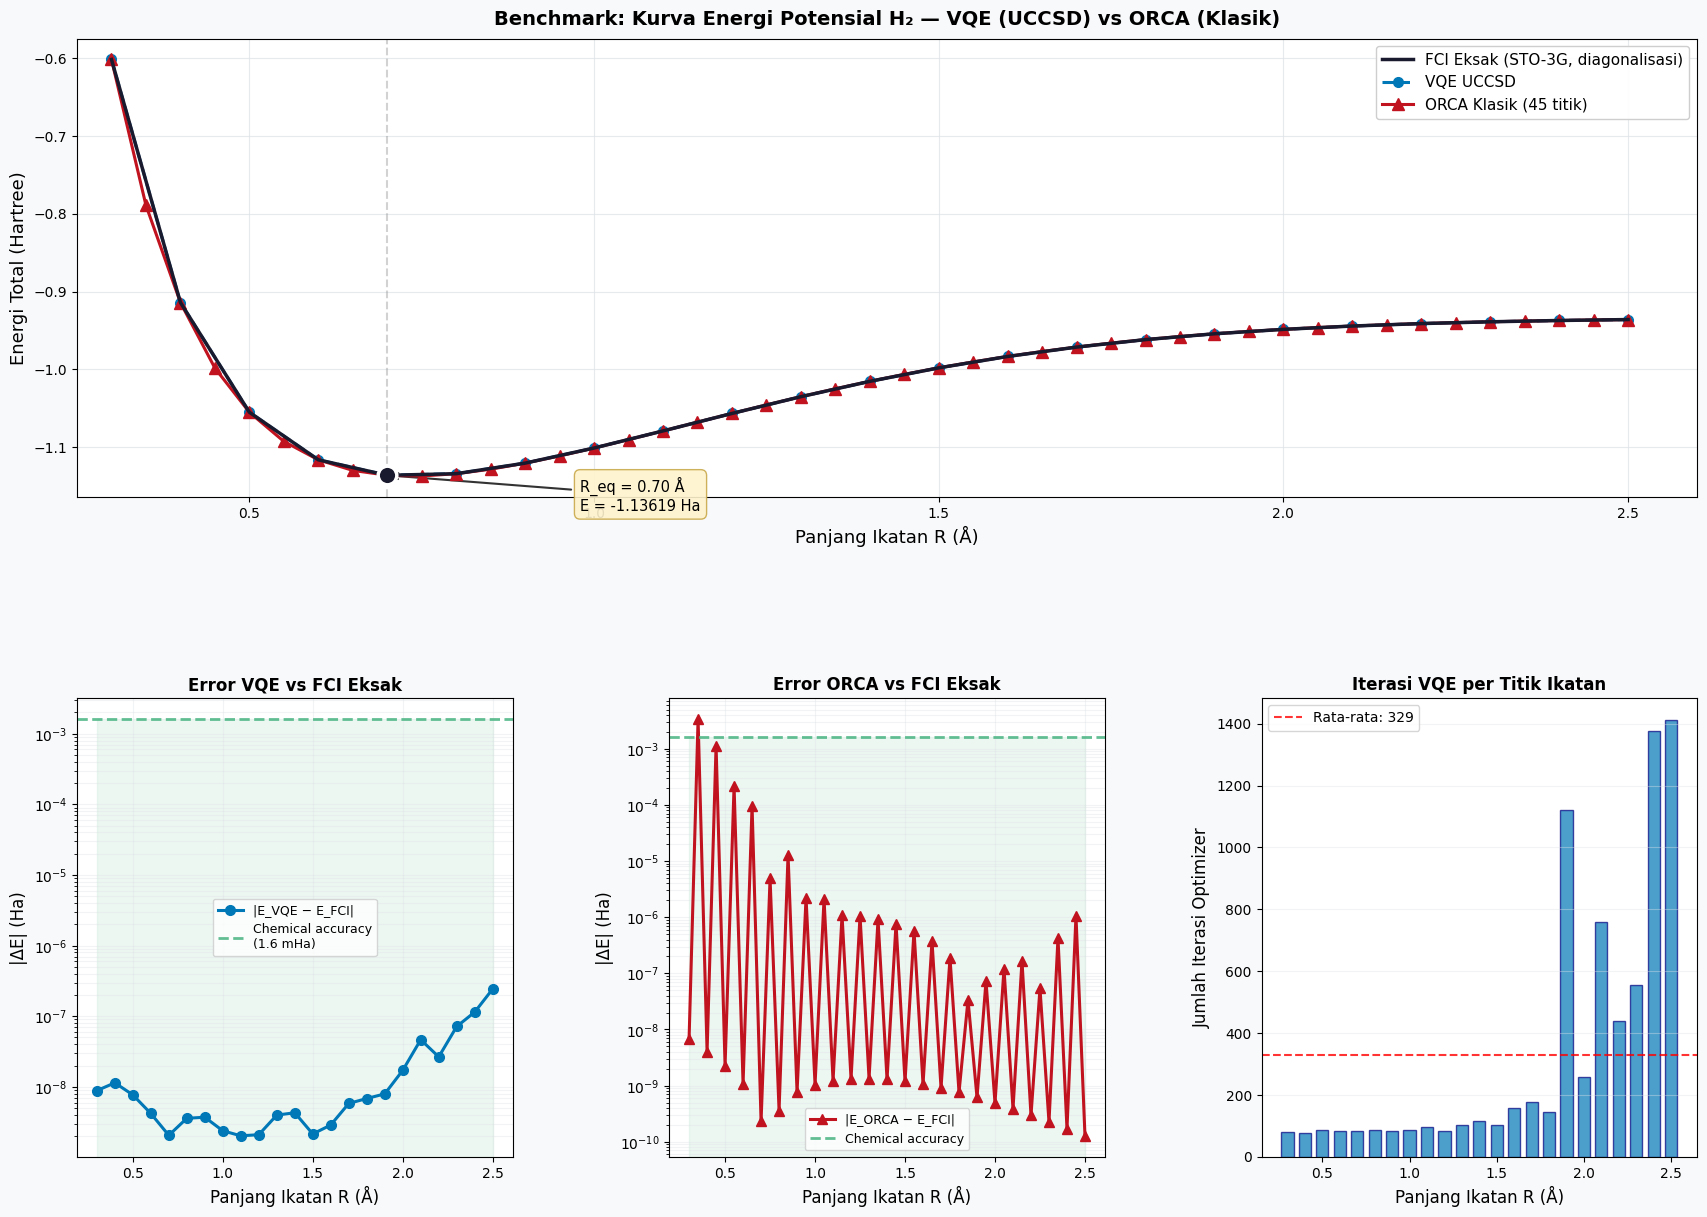

✅ Plot disimpan: benchmark_vqe_orca_H2.png


In [8]:
R_vqe  = np.array([r['R']      for r in results_vqe])
E_fci  = np.array([r['E_fci']  for r in results_vqe])
# E_hf   = np.array([r['E_hf']   for r in results_vqe])
E_vqe  = np.array([r['E_vqe']  for r in results_vqe])
dE_vqe = np.array([r['dE_vqe'] for r in results_vqe])
iters  = np.array([r['n_iters'] for r in results_vqe])

R_orca = np.array(list(orca_data.keys()))
E_orca = np.array(list(orca_data.values()))
has_orca = len(R_orca) > 0

# Error ORCA vs FCI
if has_orca:
    fci_interp = interp1d(R_vqe, E_fci, kind='cubic', fill_value='extrapolate')
    R_min_s = max(R_vqe.min(), R_orca.min())
    R_max_s = min(R_vqe.max(), R_orca.max())
    mask_orca = (R_orca >= R_min_s) & (R_orca <= R_max_s)
    E_fci_at_orca = fci_interp(R_orca[mask_orca])
    dE_orca = np.abs(E_orca[mask_orca] - E_fci_at_orca)

# ── Warna & Style ────────────────────────────────────────────────────
C = {'fci':'#1a1a2e', 'vqe':'#0077b6', 'hf':'#e07c00',
     'orca':'#c1121f', 'chem':'#52b788', 'grid':'#dee2e6'}

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(2, 3, hspace=0.44, wspace=0.36,
                       top=0.93, bottom=0.07, left=0.07, right=0.97)

# ── Plot 1: PES Utama ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#ffffff')
ax1.plot(R_vqe, E_fci, '-',   color=C['fci'],  lw=2.5, zorder=5,
         label='FCI Eksak (STO-3G, diagonalisasi)')
ax1.plot(R_vqe, E_vqe, 'o--', color=C['vqe'],  lw=2.2, ms=7, zorder=4,
         label='VQE UCCSD')
# ax1.plot(R_vqe, E_hf,  's:',  color=C['hf'],   lw=1.6, ms=6, zorder=3, alpha=0.8,
#         label='Hartree-Fock (θ=0)')
if has_orca:
    ax1.plot(R_orca, E_orca, '^-', color=C['orca'], lw=2.2, ms=8, zorder=4,
             label=f'ORCA Klasik ({len(R_orca)} titik)')

# Tandai minimum FCI
idx_min = np.argmin(E_fci)
ax1.axvline(R_vqe[idx_min], color='gray', ls='--', alpha=0.35, lw=1.5)
ax1.scatter([R_vqe[idx_min]], [E_fci[idx_min]], s=180,
            color=C['fci'], zorder=10, edgecolor='white', lw=2.5)
ax1.annotate(f'R_eq = {R_vqe[idx_min]:.2f} Å\nE = {E_fci[idx_min]:.5f} Ha',
             xy=(R_vqe[idx_min], E_fci[idx_min]),
             xytext=(R_vqe[idx_min]+0.28, E_fci[idx_min]-0.045),
             fontsize=10.5,
             bbox=dict(boxstyle='round,pad=0.4', fc='#fff3cd', alpha=0.9, ec='#c9a94b'),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

ax1.set_xlabel('Panjang Ikatan R (Å)', fontsize=13)
ax1.set_ylabel('Energi Total (Hartree)', fontsize=13)
ax1.set_title('Benchmark: Kurva Energi Potensial H₂ — VQE (UCCSD) vs ORCA (Klasik)',
              fontsize=14, weight='bold', pad=10)
ax1.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax1.grid(True, color=C['grid'], alpha=0.7)
ax1.set_xlim(0.25, 2.6)

# ── Plot 2: Error VQE vs FCI ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#ffffff')
ax2.semilogy(R_vqe, dE_vqe, 'o-', color=C['vqe'], lw=2.2, ms=7,
             label='|E_VQE − E_FCI|')
ax2.axhline(1.6e-3, color=C['chem'], ls='--', lw=2, alpha=0.9,
            label='Chemical accuracy\n(1.6 mHa)')
ax2.fill_between(R_vqe, 0, 1.6e-3, alpha=0.1, color=C['chem'])
ax2.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax2.set_ylabel('|ΔE| (Ha)', fontsize=12)
ax2.set_title('Error VQE vs FCI Eksak', fontsize=12, weight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, which='both', color=C['grid'])

# ── Plot 3: Error ORCA vs FCI ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#ffffff')
if has_orca:
    ax3.semilogy(R_orca[mask_orca], dE_orca, '^-', color=C['orca'], lw=2.2, ms=7,
                 label='|E_ORCA − E_FCI|')
    ax3.axhline(1.6e-3, color=C['chem'], ls='--', lw=2, alpha=0.9,
                label='Chemical accuracy')
    ax3.fill_between(R_orca[mask_orca], 0, 1.6e-3, alpha=0.1, color=C['chem'])
    ax3.legend(fontsize=9)
else:
    ax3.text(0.5, 0.5, 'Data ORCA\ntidak ditemukan',
             ha='center', va='center', transform=ax3.transAxes,
             fontsize=13, color='gray')
ax3.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax3.set_ylabel('|ΔE| (Ha)', fontsize=12)
ax3.set_title('Error ORCA vs FCI Eksak', fontsize=12, weight='bold')
ax3.grid(True, alpha=0.4, which='both', color=C['grid'])

# ── Plot 4: Iterasi VQE ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('#ffffff')
ax4.bar(R_vqe, iters, width=0.07, color=C['vqe'], alpha=0.7, edgecolor='navy')
avg_iter = iters.mean()
ax4.axhline(avg_iter, color='red', ls='--', lw=1.5, alpha=0.8,
            label=f'Rata-rata: {avg_iter:.0f}')
ax4.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax4.set_ylabel('Jumlah Iterasi Optimizer', fontsize=12)
ax4.set_title('Iterasi VQE per Titik Ikatan', fontsize=12, weight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.4, axis='y', color=C['grid'])

plt.savefig('benchmark_vqe_orca_H2.png', dpi=180, bbox_inches='tight')
plt.show()
print('✅ Plot disimpan: benchmark_vqe_orca_H2.png')